In [8]:
import pandas as pd
import json

# put your summary file path here
summary_file = "/home/akapociu/ift/interactiondynamics/results/iftxbaseline_all_ds.jsonl"

# read jsonl into dataframe
rows = []
with open(summary_file, "r") as f:
    for line in f:
        rows.append(json.loads(line))

df = pd.DataFrame(rows)

def parse_name(name):
    parts = {}
    for x in str(name).split("|"):
        if "=" in x:
            key, value = x.split("=", 1)

            # fix keys like "MOOC_agg" -> "agg"
            if "_" in key:
                key = key.split("_")[-1]

            parts[key] = value

    return pd.Series({
        "agg": parts.get("agg"),
        "update": parts.get("update"),
        "dropout": "yes" if ((float(parts.get("do", 0.0)) > 0) or (float(parts.get("sdo", 0.0)) > 0)) else "no"
    })

parsed = df["name"].apply(parse_name)
df = pd.concat([df, parsed], axis=1)

# sort
df = df.sort_values(["best_val_mrr"], ascending=False)

df["global_rank"] = range(1, len(df) + 1)
# final clean table
final_table = df[[
    "global_rank",
    "dataset",
    "agg",
    "update",
    "dropout",
    "best_val_mrr",
    "best_epoch"
]]

final_table

,global_rank,dataset,agg,update,dropout,best_val_mrr,best_epoch
24,1,LastFM,sum,ift_update,no,0.999949,6
21,2,MOOC,ift,tgn_gru,no,0.982031,6
19,3,MOOC,sum,tgn_gru,yes,0.967632,10
23,4,MOOC,ift,tgn_gru,yes,0.964918,2
17,5,MOOC,sum,tgn_gru,no,0.962545,4
16,6,MOOC,sum,ift_update,no,0.960694,1
18,7,MOOC,sum,ift_update,yes,0.960101,1
22,8,MOOC,ift,ift_update,yes,0.956238,2
20,9,MOOC,ift,ift_update,no,0.952208,9
15,10,Reddit,ift,tgn_gru,yes,0.944321,8


In [9]:
for dataset in final_table["dataset"].unique():
    print(f"\n=== {dataset} ===")
    display(final_table[final_table["dataset"] == dataset].reset_index(drop=True))


=== LastFM ===


,global_rank,dataset,agg,update,dropout,best_val_mrr,best_epoch
0,1,LastFM,sum,ift_update,no,0.999949,6
1,26,LastFM,sum,tgn_gru,no,0.453424,9
2,27,LastFM,ift,tgn_gru,yes,0.438147,3
3,28,LastFM,sum,tgn_gru,yes,0.434868,5
4,29,LastFM,ift,tgn_gru,no,0.430114,1
5,30,LastFM,ift,ift_update,no,0.426335,8
6,31,LastFM,ift,ift_update,yes,0.425885,4
7,32,LastFM,sum,ift_update,yes,0.268723,2



=== MOOC ===


,global_rank,dataset,agg,update,dropout,best_val_mrr,best_epoch
0,2,MOOC,ift,tgn_gru,no,0.982031,6
1,3,MOOC,sum,tgn_gru,yes,0.967632,10
2,4,MOOC,ift,tgn_gru,yes,0.964918,2
3,5,MOOC,sum,tgn_gru,no,0.962545,4
4,6,MOOC,sum,ift_update,no,0.960694,1
5,7,MOOC,sum,ift_update,yes,0.960101,1
6,8,MOOC,ift,ift_update,yes,0.956238,2
7,9,MOOC,ift,ift_update,no,0.952208,9



=== Reddit ===


,global_rank,dataset,agg,update,dropout,best_val_mrr,best_epoch
0,10,Reddit,ift,tgn_gru,yes,0.944321,8
1,11,Reddit,ift,tgn_gru,no,0.944284,10
2,12,Reddit,sum,tgn_gru,no,0.929067,5
3,13,Reddit,sum,tgn_gru,yes,0.919055,8
4,14,Reddit,sum,ift_update,no,0.896200,6
5,15,Reddit,sum,ift_update,yes,0.892834,9
6,16,Reddit,ift,ift_update,yes,0.891737,5
7,17,Reddit,ift,ift_update,no,0.873594,4



=== Wikipedia ===


,global_rank,dataset,agg,update,dropout,best_val_mrr,best_epoch
0,18,Wikipedia,sum,tgn_gru,no,0.862729,8
1,19,Wikipedia,ift,tgn_gru,no,0.860842,7
2,20,Wikipedia,ift,tgn_gru,yes,0.860098,1
3,21,Wikipedia,sum,tgn_gru,yes,0.844572,6
4,22,Wikipedia,ift,ift_update,yes,0.815848,2
5,23,Wikipedia,ift,ift_update,no,0.814892,1
6,24,Wikipedia,sum,ift_update,no,0.720319,1
7,25,Wikipedia,sum,ift_update,yes,0.718662,1


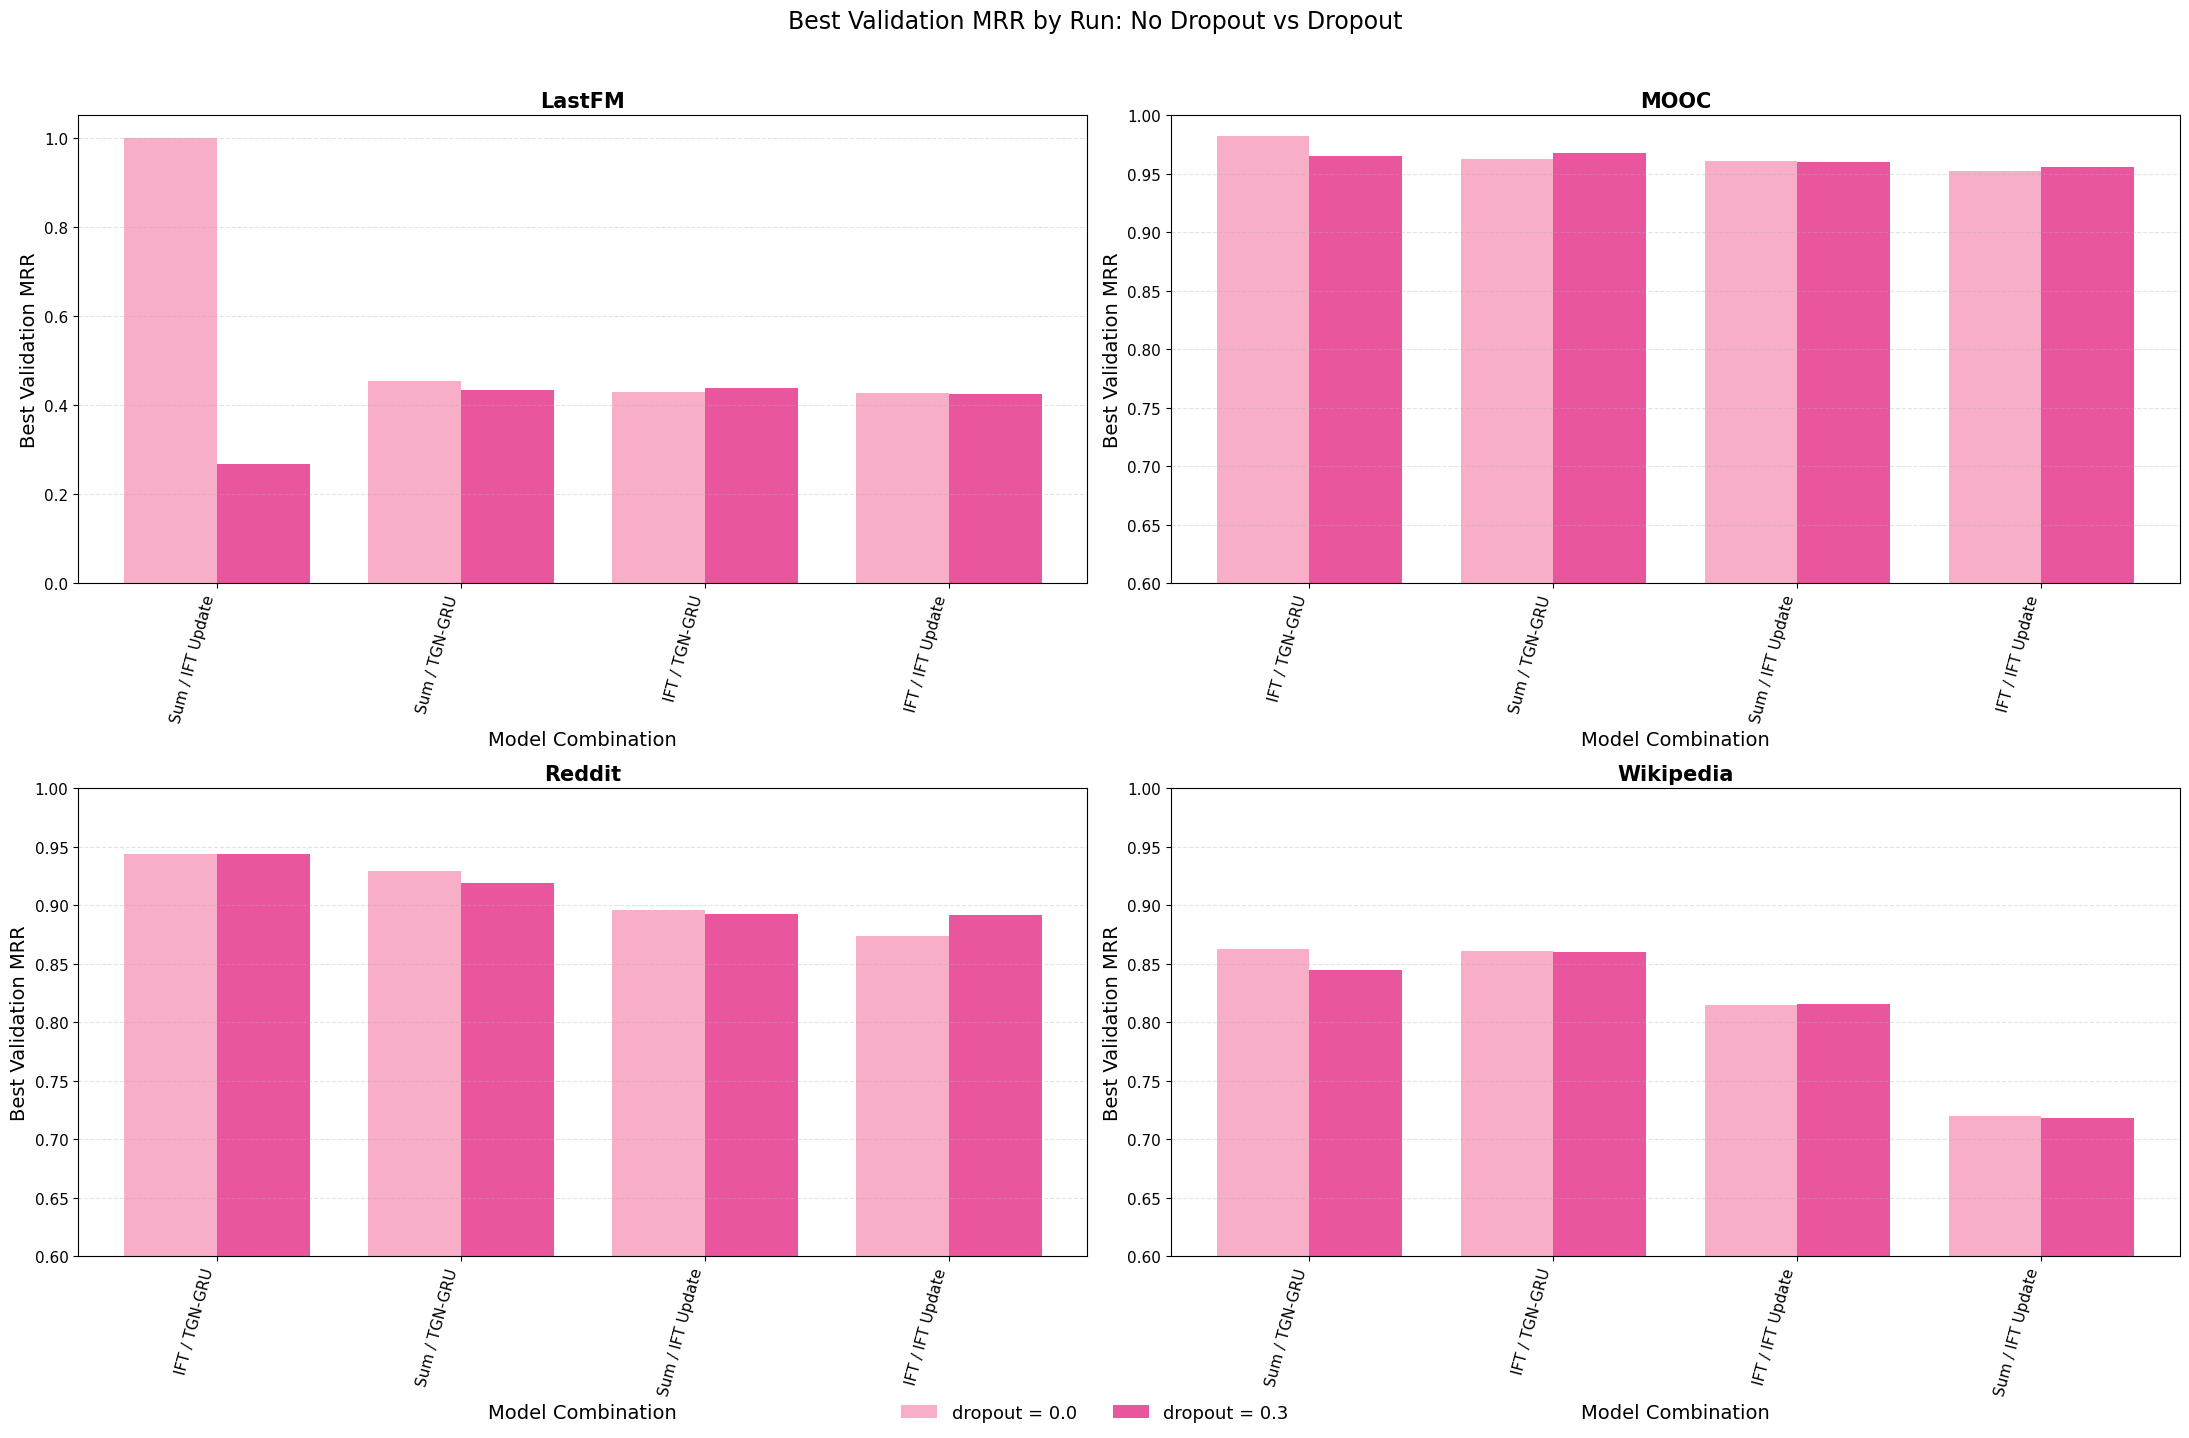

In [11]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# helpers
# -----------------------------
def extract_combo_label(name):
    if name is None:
        return ""

    s = str(name)

    agg = None
    upd = None

    m = re.search(r'agg=([^|]+)', s)
    if m:
        agg = m.group(1)

    m = re.search(r'update=([^|]+)', s)
    if m:
        upd = m.group(1)

    PRETTY = {
        "ift": "IFT",
        "sum": "Sum",
        "deepsets": "DeepSets",
        "hopfield": "Hopfield",
        "settransformer": "SetTransformer",
        "ift_update": "IFT Update",
        "tgn_gru": "TGN-GRU",
        "hopfield_update": "Hopfield Update",
        "identity": "Identity",
        "lnn": "LNN",
        "hnn": "HNN",
    }

    agg_pretty = PRETTY.get(agg, agg)
    upd_pretty = PRETTY.get(upd, upd)

    if agg_pretty and upd_pretty:
        return f"{agg_pretty} / {upd_pretty}"
    elif agg_pretty:
        return agg_pretty
    elif upd_pretty:
        return upd_pretty
    else:
        return s


def get_dropout_from_name(name):
    if name is None:
        return np.nan
    s = str(name)
    vals = [float(m) for m in re.findall(r'(?:^|[|])(?:do|sdo)=([0-9]*\.?[0-9]+)', s)]
    return max(vals) if vals else 0.0


def strip_dropout_from_name(name):
    if name is None:
        return None
    s = str(name)
    s = re.sub(r'\|do=[0-9]*\.?[0-9]+', '', s)
    s = re.sub(r'\|sdo=[0-9]*\.?[0-9]+', '', s)
    s = re.sub(r'\|\|+', '|', s)
    s = s.strip('|')
    return s


# -----------------------------
# build plotting dataframe
# -----------------------------
plot_df = df.copy()
plot_df = plot_df[plot_df["best_val_mrr"].notna()].copy()

plot_df["dropout_val"] = plot_df["name"].apply(get_dropout_from_name)
plot_df["pair_key"] = plot_df["name"].apply(strip_dropout_from_name)

plot_df = plot_df[plot_df["dropout_val"].isin([0.0, 0.3])].copy()

plot_df = (
    plot_df.sort_values("best_val_mrr", ascending=False)
           .drop_duplicates(subset=["dataset", "pair_key", "dropout_val"])
)

DATASET_ORDER = sorted(plot_df["dataset"].dropna().unique())

# -----------------------------
# styling
# -----------------------------
color_no_dropout = "#f8a5c2"   # soft pink
color_dropout    = "#e84393"   # stronger pink

title_fs = 15
axis_label_fs = 14
tick_fs = 11
legend_fs = 13
subplot_title_fs = 15

# -----------------------------
# plot
# -----------------------------
fig, axes = plt.subplots(2, 2, figsize=(22, 14), sharey=False)
axes = axes.flatten()

bar_width = 0.38

for ax, ds in zip(axes, DATASET_ORDER):
    sub = plot_df[plot_df["dataset"] == ds].copy()

    wide = (
        sub.pivot(index="pair_key", columns="dropout_val", values="best_val_mrr")
           .rename(columns={0.0: "dropout_0.0", 0.3: "dropout_0.3"})
    )

    wide["sort_col"] = wide["dropout_0.0"].fillna(wide["dropout_0.3"])
    wide = wide.sort_values("sort_col", ascending=False).drop(columns="sort_col")

    x = np.arange(len(wide))

    y0 = wide["dropout_0.0"].values if "dropout_0.0" in wide.columns else np.full(len(wide), np.nan)
    y1 = wide["dropout_0.3"].values if "dropout_0.3" in wide.columns else np.full(len(wide), np.nan)

    ax.bar(
        x - bar_width / 2,
        y0,
        width=bar_width,
        label="dropout = 0.0",
        alpha=0.9,
        color=color_no_dropout
    )
    ax.bar(
        x + bar_width / 2,
        y1,
        width=bar_width,
        label="dropout = 0.3",
        alpha=0.9,
        color=color_dropout
    )

    ax.set_title(ds, fontsize=subplot_title_fs, weight="bold")
    ax.set_ylabel("Best Validation MRR", fontsize=axis_label_fs)
    ax.set_xlabel("Model Combination", fontsize=axis_label_fs)

    labels = [extract_combo_label(idx) for idx in wide.index]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=75, ha="right", fontsize=tick_fs)
    ax.tick_params(axis="y", labelsize=tick_fs)

    ax.grid(axis="y", linestyle="--", alpha=0.35)

    if ds in ["MOOC", "Reddit", "Wikipedia"]:
        ax.set_ylim(0.6, 1.0)

# turn off unused axes
for j in range(len(DATASET_ORDER), len(axes)):
    axes[j].axis("off")

legend_handles = [
    Patch(facecolor=color_no_dropout, edgecolor="none", label="dropout = 0.0", alpha=0.9),
    Patch(facecolor=color_dropout, edgecolor="none", label="dropout = 0.3", alpha=0.9),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=2,
    frameon=False,
    fontsize=legend_fs
)

fig.suptitle(
    "Best Validation MRR by Run: No Dropout vs Dropout",
    fontsize=title_fs + 2,
    y=1.02
)

plt.tight_layout()
fig.savefig("mrr_droput_vs_no_dropout.png", dpi=300, bbox_inches="tight")
plt.show()